# Introduction

In this notebook, we illustrate our implementation of the semi-analytical European option pricing formula under an Improved Stein-Stein model (LLH) as derived in Lin, Lin & He (2024, *Analytically Pricing European Options under a New Two-Factor Stochastic Volatility Model*). The prices obtained from the formula are compared to Monte Carlo prices and the implmentation is tested against edge cases where the LLH model reduces to the classical Black-Scholes model and the stochastic volatility models of Stein-Stein (1990, *Stock price distributions with stochastic volatility*) and Schobel-Zhu (1999, *Stochastic volatility with an Ornstein-Uhlenbeck:an extension*).



### Note on the LLH paper

Our implementation corrects an error present in the formula of Lin, Lin & He (2024).  Specifically, the ODE system for the characteristic function coefficients $D,\,E,\,F,\,G,\,H$ (shown below) is **autonomous** — it depends only on the current state, not on the time to maturity $\tau$. The paper's presentation suggests a  $\tau$-dependent right-hand side for $\frac{\partial D}{\partial \tau}$, which is incorrect.

The close agreement between our rectified numerical LLH prices and independent Monte Carlo estimates throughout this notebook serves as evidence that this correction is valid.

---

**v1 notebook** — runs against `priceModels` (single-scheme, batched Euler on the full LLH SDE with 3 independent Brownians). See `src/priceModels.py`.


## Contents

1. [LLH Model](#llh-model) 
2. [Price Paths Simulation](#simulate)
3. [LLH Pricing Forumla](#llh-formula) 
4. [LLH Formula vs Monte Carlo](#european-prices)
   - 3.1 One-month horizon
   - 3.2 One-year horizon
5. [Timing: Numerical LLH vs Monte Carlo](#timing) 
6. [Edge-Case Validation](#edge-cases)
   - 5.1 Black-Scholes model (1973) 
   - 5.2 Stein & Stein model (1991)  
   - 5.3 Schöbel & Zhu model (1999) 

<a id="llh-model"></a>
## 1. Improved Stein-Stein Model (LLH)

\begin{align}
    \frac{dS_t}{S_t} &= rdt + \sigma_tdW^1_t\\
    d\sigma_t &= \kappa(\theta_t-\sigma_t)dt + \nu dW^2_t\\
    d\theta_t &= \lambda dt + \eta dB_t\\
    dB_t &= B_t dW_t,\,B_0=1\\
    \text{ }\notag\\
    \text{cov}&(W^1_t,W^2_t)=\rho t \notag
\end{align}

- $W^1_t,\,W^2_t$ are correlated Brownian motions, $W_t$ independent Brownian motion
- $\Theta = (\kappa,\,\nu,\,\lambda,\,\eta,\, \rho)$ are the model parameters

<a id="simulate"></a>
## 2. Price Paths Simulation

We illustrate simulation of price paths from the LLH model following Algorithm 2.5 found in the report.
Model parameters are taken from the Lin-Lin-He paper, Tables 1 and 2 respectively. Here, $10, 000$ thousand paths are sampled over a $1-$year horizon with $252$ trading days.

In [1]:
import sys, time
sys.path.insert(0, '../src')

import priceModels as pm
import reporting
reporting.pm = pm  # route reporting helpers through v1

from amerPrice import price_call_bs
from reporting import llh_vs_mc, llh_vs_mc_timing, sz_table2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


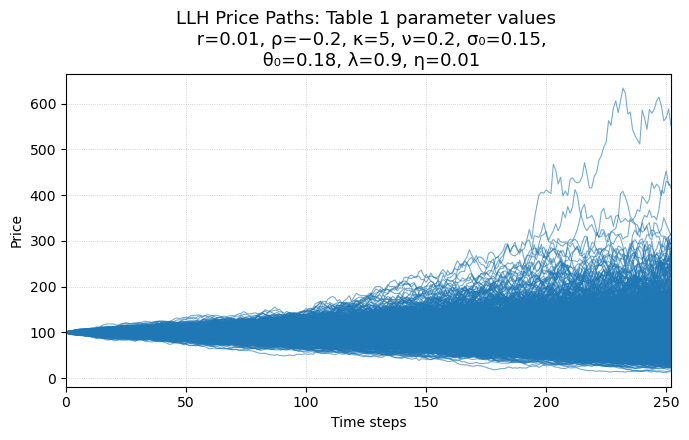

In [6]:
# Model with Lin-Lin-He paper-Table 1 parameters
model_t1 = pm.ImprovedSteinStein(
    r=0.01, rho=-0.2, kappa=5, nu=0.2,
    sigma0=0.15, theta0=0.18, lam=0.9, eta=0.01, seed=123
)

# Simulate and plot price paths
res_t1 = model_t1.simulate_prices(S0=100.0, T=1.0, n_steps_mc=252, n_paths=1000)
pm.plot(res_t1['S'].T, title="LLH Price Paths: Table 1 parameter values \n r=0.01, ρ=−0.2, κ=5, ν=0.2, σ₀=0.15,\n θ₀=0.18, λ=0.9, η=0.01")

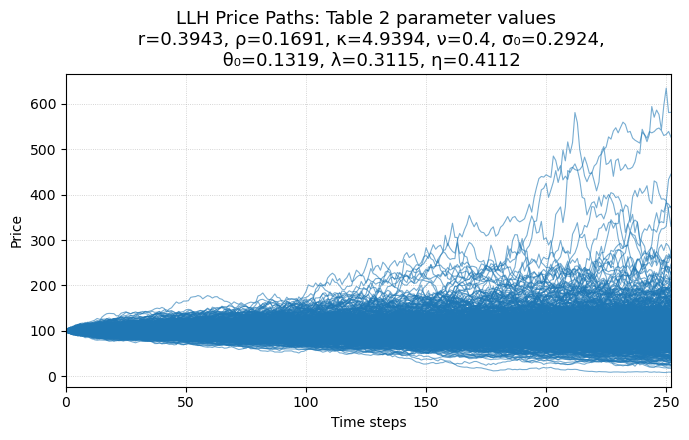

In [7]:
# Model with Lin-Lin-He paper-Table 2 parameters
model_t2 = pm.ImprovedSteinStein(
    r=0.01, rho=0.1691, kappa=4.9394, nu=0.3943,
    sigma0=0.2924, theta0=0.1319, lam=0.3115, eta=0.4112, seed=123
)

# Simulate and plot price paths
res_t2 = model_t2.simulate_prices(S0=100.0, T=1.0, n_steps_mc=252, n_paths=1000)
pm.plot(res_t2['S'].T, title="LLH Price Paths: Table 2 parameter values \n r=0.3943, ρ=0.1691, κ=4.9394, ν=0.4, σ₀=0.2924,\n θ₀=0.1319, λ=0.3115, η=0.4112")

<a id="llh-pricing"></a>
## 3. LLH Pricing Formula

The price $U$ of a European option under LLh model is computed using the following formula derived in Lin, Lin & He (2024).

$$
U(\tau;S_t,K)
= S_t\,P_1(\tau;K) - K e^{-r\tau}\,P_2(\tau;K)
$$
where for $j=1,2:$

\begin{equation}
\begin{aligned}
    P_j(\tau;K) 
&= \tfrac{1}{2}
  + \frac{1}{\pi}\int_{0}^{\infty}
      Re\left[
        \frac{e^{-i\phi\ln K}}{i\phi}\,
        f_j(\tau;\phi)
      \right]\,d\phi\\
f_j(\tau;\phi)
&= \exp\!\big(
  C + D\,\sigma_t^2 + E\,\sigma_t\theta_t + F\,\theta_t^2 + G\,\theta_t + H\,\sigma_t + i\phi\,x_t
\big)
\end{aligned}
\end{equation}

where $x_t=\ln S_t$ and the parameters $D,\,E,\,F,\,G,\,H$ satisfy the system of ODEs:

\begin{equation}
\begin{aligned}
\frac{\partial D}{\partial \tau}(\tau;\phi)
&= \left(u_j\, i\phi - \tfrac{1}{2}\phi^2\right)
   + 2\nu^{2} D^2(\tau;\phi) - 2A(\phi)\,D(\tau;\phi)
   + \tfrac{1}{2}\eta^{2} E^2(\tau;\phi), \\[4pt]
\frac{\partial E}{\partial \tau}(\tau;\phi)
&= 2\kappa\,D(\tau;\phi) - A(\phi)\,E(\tau;\phi)
   + 2\nu^{2} D(\tau;\phi)E(\tau;\phi)
   + 2\eta^{2} E(\tau;\phi)F(\tau;\phi), \\[4pt]
\frac{\partial F}{\partial \tau}(\tau;\phi)
&= \kappa\,E(\tau;\phi)
   + \tfrac{1}{2}\nu^{2} E^2(\tau;\phi)
   + 2\eta^{2} F^2(\tau;\phi), \\[4pt]
\frac{\partial G}{\partial \tau}(\tau;\phi)
&= \kappa\,H(\tau;\phi) + 2\lambda\,F(\tau;\phi)
   + \nu^{2} E(\tau;\phi)H(\tau;\phi)
   + 2\eta^{2} F(\tau;\phi)G(\tau;\phi), \\[4pt]
\frac{\partial H}{\partial \tau}(\tau;\phi)
&= -A(\phi)\,H(\tau;\phi) + \lambda\,E(\tau;\phi)
   + 2\nu^{2} D(\tau;\phi)H(\tau;\phi)
   + \eta^{2} E(\tau;\phi)G(\tau;\phi), \\[4pt]
\frac{\partial C}{\partial \tau}(\tau;\phi)
&= r\, i\phi + \lambda\,G(\tau;\phi)
   + \tfrac{1}{2}\nu^{2} H^2(\tau;\phi) + \nu^{2} D(\tau;\phi)
   + \tfrac{1}{2}\eta^{2} G^2(\tau;\phi) + \eta^{2} F(\tau;\phi)
\end{aligned}
\end{equation}
with $u_1=\tfrac{1}{2},\, u_2=-\tfrac{1}{2},\,
b_1=1,\, b_2=0,\,
A(\phi)=\kappa-\nu\rho\,(b_j+i\phi), \, x=\ln S_t$ and the initial conditions 
$$C(0;\phi)=D(0;\phi)=E(0;\phi)=F(0;\phi)=G(0;\phi)=H(0;\phi)=0$$

Here, $\tau = T-t$ is the remaining time until maturity of the option and $\phi$ is a dummy (frequency) parameter.

In [10]:
#Set options parameters
S0, K, tau = 100.0, 90.0, 1.0

#Set Quadrature and ODE solver parameters
phi_max, n_phi, n_steps_ode = 300.0, 500, 100

# Price European call via LLH formula for Table 1 parameters
print(
    model_t1.price_call_llh(S=S0, K=K, tau=tau,                                   
                        phi_max=phi_max, n_phi=n_phi, n_steps_ode=n_steps_ode,
                        vol=model_t1.sigma0, theta=model_t1.theta0)
)

[25.79140282]


<a id="european-prices"></a>
## 4. LLH Formula vs Monte Carlo

We compute European option prices using the rectified semi-analytical formula from
Lin, Lin & He (2024) and compare with Monte Carlo
estimates from 1,000,000 simulated paths. Results are shown for both
parameter sets (Tables 1 and 2 from LLH paper) across two time horizons: one month and one year. Scenarios have been considered for in-the-money, at-the-money, and out-the-money options.


### Note on Pricing European Puts 

* The LLH price of a European put has been computed using the call-put partiy: $P_E^{\text{LLH}} = C_E^{\text{LLH}} + Ke^{-r\tau} - S$
* The MC price a European put has been computed as $P_E^{\text{MC}} = \mathbb{E}\left[e^{-r\tau}\max(0, K-S_T)\right]$

### 4.1 One-month horizon ($\tau = 1/12$ yr, 22 trading days)

In [4]:
# Set parameters for option pricing
# Spot price values
S_vals = [90.0, 95.0, 100.0, 105.0, 110.0]

# Strike price values 
K_vals = [100.0, 90.0, 100.0, 110.0, 105.0]

# Time to maturity
tau = 0.083

# Number of trading days in a month, used for Monte Carlo time step
n_steps_mc = 22

# Monte Carlo 
n_paths = 1_000_000

#### Lin, Lin & He (2024) — Table 1 parameters

In [11]:
# Compute and display option prices
call_df, put_df = llh_vs_mc(model_t1, S_vals, K_vals, tau=tau, n_steps_mc=n_steps_mc,
                                  n_paths=n_paths, phi_max=phi_max, n_phi=n_phi, n_steps_ode=n_steps_ode)

In [14]:
print("European Call Prices")
display(call_df)

European Call Prices


,K,LLH,MC,Bias (%),MC 95% CI
S₀,,,,,
90.0,100.0,0.020092,0.019497,-3.05,"[0.0190, 0.0200]"
95.0,90.0,5.373783,5.367087,-0.12,"[5.3593, 5.3748]"
100.0,100.0,1.899232,1.889459,-0.52,"[1.8840, 1.8949]"
105.0,110.0,0.413589,0.407162,-1.58,"[0.4045, 0.4098]"
110.0,105.0,5.544537,5.535930,-0.16,"[5.5273, 5.5446]"


In [15]:
print("European Put Prices")
display(put_df)

European Put Prices


,K,LLH,MC,Bias (%),MC 95% CI
S₀,,,,,
90.0,100.0,9.937126,9.938710,0.02,"[9.9305, 9.9469]"
95.0,90.0,0.299114,0.294717,-1.49,"[0.2926, 0.2968]"
100.0,100.0,1.816267,1.808914,-0.41,"[1.8035, 1.8143]"
105.0,110.0,5.322327,5.318441,-0.07,"[5.3101, 5.3268]"
110.0,105.0,0.457423,0.451479,-1.32,"[0.4486, 0.4543]"


We notice that the relative bias jumps modestly for options priced at out-the-money spot.

#### Lin, Lin & He (2024) — Table 2 parameters

In [16]:
# Compute and display option prices
call_df, put_df = llh_vs_mc(model_t2, S_vals, K_vals, tau=tau, n_steps_mc=n_steps_mc,
                                  n_paths=n_paths, phi_max=phi_max, n_phi=n_phi, n_steps_ode=n_steps_ode)

In [17]:
print("European Call Prices")
display(call_df)

European Call Prices


,K,LLH,MC,Bias (%),MC 95% CI
S₀,,,,,
90.0,100.0,0.392372,0.391271,-0.28,"[0.3877, 0.3948]"
95.0,90.0,6.066585,6.071880,0.09,"[6.0595, 6.0842]"
100.0,100.0,3.140889,3.148204,0.23,"[3.1382, 3.1582]"
105.0,110.0,1.506520,1.508991,0.16,"[1.5016, 1.5164]"
110.0,105.0,6.445675,6.452594,0.11,"[6.4387, 6.4665]"


In [18]:
print("European Put Prices")
display(put_df)

European Put Prices


,K,LLH,MC,Bias (%),MC 95% CI
S₀,,,,,
90.0,100.0,10.309406,10.311505,0.02,"[10.2991, 10.3240]"
95.0,90.0,0.991916,1.000588,0.87,"[0.9959, 1.0053]"
100.0,100.0,3.057923,3.068793,0.35,"[3.0604, 3.0772]"
105.0,110.0,6.415257,6.421461,0.10,"[6.4096, 6.4333]"
110.0,105.0,1.358561,1.369390,0.79,"[1.3635, 1.3753]"


For this set of model parameters, the relative bias remains within 1% for all options types. The price process resulting from the model under these parameters is more volatile and the model seems to gauage the price well in this case.

### 4.2 One-year horizon ($\tau = 1.0$ yr, 52 weekly steps)

In [12]:
# Time to maturity
tau = 1.0

# Number of trading days in a month, used for Monte Carlo time step
n_steps_mc = 52

# Reduce number of paths to 500,000 to reduce computational cost
n_paths = 500_000


#### Lin, Lin & He (2024) — Table 1 parameters

In [13]:
# Compute and display option prices 
call_df, put_df = llh_vs_mc(model_t1, S_vals, K_vals, tau=tau, n_steps_mc=n_steps_mc,
                                  n_paths=n_paths, phi_max=phi_max, n_phi=n_phi, n_steps_ode=n_steps_ode)

In [21]:
print("European Call Prices")
display(call_df)

European Call Prices


,K,LLH,MC,Bias (%),MC 95% CI
S₀,,,,,
90.0,100.0,15.604471,15.268998,-2.20,"[15.1726, 15.3654]"
95.0,90.0,22.428989,22.096958,-1.50,"[21.9826, 22.2114]"
100.0,100.0,21.388416,21.027373,-1.72,"[20.9112, 21.1435]"
105.0,110.0,20.529176,20.143361,-1.92,"[20.0255, 20.2612]"
110.0,105.0,25.623710,25.237398,-1.53,"[25.1056, 25.3692]"


In [14]:
print("European Put Prices")
display(put_df)

European Put Prices


,K,LLH,MC,Bias (%),MC 95% CI
S₀,,,,,
90.0,100.0,24.609455,24.317096,-1.20,"[24.2511, 24.3831]"
95.0,90.0,16.533474,16.246954,-1.76,"[16.1925, 16.3014]"
100.0,100.0,20.393399,20.080262,-1.56,"[20.0176, 20.1429]"
105.0,110.0,24.434657,24.099143,-1.39,"[24.0285, 24.1698]"
110.0,105.0,19.578943,19.245326,-1.73,"[19.1815, 19.3092]"


#### Lin, Lin & He (2024) — Table 2 parameters

In [15]:
call_df, put_df = llh_vs_mc(model_t2, S_vals, K_vals, tau=tau, n_steps_mc=n_steps_mc,
                                  n_paths=n_paths, phi_max=phi_max, n_phi=n_phi, n_steps_ode=n_steps_ode)

In [16]:
print("European Call Prices")
display(call_df)

European Call Prices


,K,LLH,MC,Bias (%),MC 95% CI
S₀,,,,,
90.0,100.0,8.728264,8.620706,-1.25,"[8.5510, 8.6905]"
95.0,90.0,15.353155,15.238291,-0.75,"[15.1541, 15.3225]"
100.0,100.0,13.678589,13.559070,-0.88,"[13.4740, 13.6441]"
105.0,110.0,12.367477,12.242390,-1.02,"[12.1565, 12.3283]"
110.0,105.0,17.377769,17.244956,-0.77,"[17.1480, 17.3419]"


In [25]:
print("\nEuropean Put Prices")
display(put_df)


European Put Prices


,K,LLH,MC,Bias (%),MC 95% CI
S₀,,,,,
90.0,100.0,17.733248,17.704832,-0.16,"[17.6543, 17.7553]"
95.0,90.0,9.457640,9.426316,-0.33,"[9.3865, 9.4661]"
100.0,100.0,12.683573,12.651990,-0.25,"[12.6053, 12.6987]"
105.0,110.0,16.272959,16.240205,-0.20,"[16.1868, 16.2936]"
110.0,105.0,11.333001,11.296918,-0.32,"[11.2501, 11.3437]"


Again, for this set of parameters, the relative bias jumps more significantly over the 1 year horizon for the more volatile price process.

#### Remarks
- The put-call parity: $P-C=Ke^{-r\tau}-S$ implies $C_E^{\text{LLH}}-C^{\text{MC}}_E \approx P_E^{\text{LLH}}-P^{\text{MC}}_E$, so the absolute bias is comparable for calls and puts.
- **It is worth experimenting with different sets of values of the quadrature and ODE solver parameters, and increased MC steps for in/at/out of the money options.**

<a id="timing"></a>
## 5. Timing: Numerical LLH vs Monte Carlo

We compare the wall-clock cost of computing a single European call price via
the analytical LLH formula (ODE + quadrature) versus Monte Carlo simulation,
for both the one-month and one-year horizons. Several pricing repetitions are timed and the median across runs is reported.  

In [26]:
S0, K = 100.0, 90.0
n_paths = 500_000

scenarios = [("1 month", 0.083, 22),                                                             
               ("1 year",   1.0,   52)]                                                               
display(
    llh_vs_mc_timing(model_t2, S0, K, scenarios, n_paths,                                        
                        phi_max=phi_max, n_phi=n_phi, n_steps_ode=n_steps_ode)       
)

,Label,tau,LLH,MC,Time_LLH,Time_MC,Speedup
0,1 month,0.083,10.363730,10.365228,0.033711,1.009414,29.943314
1,1 year,1.000,18.757414,18.633628,0.034728,2.761369,79.514845


<a id="edge-cases"></a>
## 5. Edge-Case Validation

We verify the LLH implementation against known limiting cases. When the
stochastic volatility parameters are switched off, the model should recover
Black-Scholes, Stein-Stein, and Schobel-Zhu prices exactly.

### 5.1 Black-Scholes (1973) limit: $\kappa=\nu=\lambda=\eta=\rho=0$

Setting all stochastic volatility parameters to zero reduces the LLH model to
geometric Brownian motion. The LLH formula should match the closed-form
Black-Scholes price to machine precision.

#### Simulate Price Paths

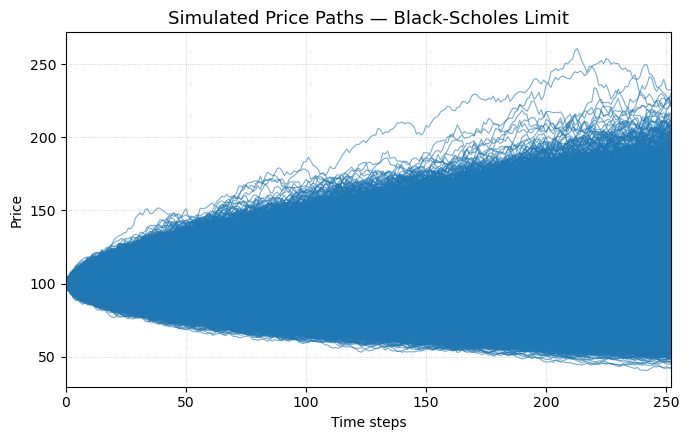

In [17]:
model_bs = pm.ImprovedSteinStein(
    r=0.05, rho=0.0, kappa=0.0, nu=0.0,
    sigma0=0.2, theta0=0.0, lam=0.0, eta=0.0, seed=123
)
res_bs = model_bs.simulate_prices(S0=100.0, T=1.0, n_steps_mc=252, n_paths=100000)
pm.plot(res_bs['S'].T, title="Simulated Price Paths — Black-Scholes Limit")

#### Test of Lognormality

We draw price paths from the LLH (BS-limit) model and consider the price slice
at the end of the horizon $T$. It should follow the BS log-normal distribution.

In [18]:
pm.test_lognormality(res_bs['S'][:, -1])

KS statistic: 0.0016, p-value: 0.9625
Fail to reject null: data may be lognormal.


#### Compare European Option Prices

In [19]:
S, K, tau, vol, theta = 100, 90, 1.0, 0.2, 0.0
price_llh = model_bs.price_call_llh(S, K, tau, vol, theta).item()
price_bs  = price_call_bs(S=100, K=90, tau=1.0, r=0.05, vol=0.2)
price_mc  = model_bs.price_call_mc(res_bs, K=90)['price']

print(f"LLH (BS-limit) = {price_llh:.10f}")
print(f"Black-Scholes  = {price_bs:.10f}")
print(f"|Δ|            = {abs(price_llh - price_bs):.3e}")
print(f"Monte Carlo    = {price_mc:.10f}")

LLH (BS-limit) = 16.6994484084
Black-Scholes  = 16.6994484084
|Δ|            = 5.684e-14
Monte Carlo    = 16.7120751556


### 5.2 Stein & Stein (1991) limit: $\lambda=\eta=\rho=0$

Setting $\lambda=\eta=0$ removes the time-varying long-run mean $\theta_t$,
and $\rho=0$ removes leverage. This recovers the original Stein & Stein (1991)
model. We compare against their Table 1 values.

#### Simulate Price Paths

Note: In the Stein-Stein paper,
$\delta := \kappa = 4, \quad k := \nu = 0.1, \quad \mu := r = 0.0953, \quad \sigma := \text{vol} = 0.2$

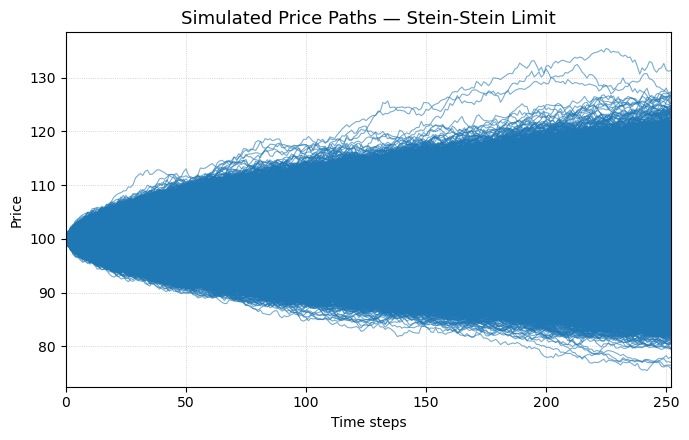

In [ ]:
model_ss = pm.ImprovedSteinStein(
    r=0.0953, rho=0.0, kappa=4.0, nu=0.1,
    sigma0=0.2, theta0=0.2, lam=0.0, eta=0.0, seed=123
)
res_ss = model_ss.simulate_prices(S0=100.0, T=1.0/12, n_steps_mc=252, n_paths=100000)
pm.plot(res_ss['S'].T, title="Simulated Price Paths — Stein-Stein Limit")

#### Compare European Option Prices

In [ ]:
S, K, tau, vol, theta = 100, 90, 1/12, 0.2, 0.2
price_llh = model_ss.price_call_llh(S, K, tau, vol, theta).item()
price_ss  = 10.77  # from Stein-Stein paper Table 1
price_mc  = model_ss.price_call_mc(res_ss, K=90)['price']

print(f"LLH (SS-limit)  = {price_llh:.10f}")
print(f"Stein-Stein     = {price_ss:.10f}")
print(f"|Δ|             = {abs(price_llh - price_ss):.3e}")
print(f"Monte Carlo     = {price_mc:.10f}")

LLH (SS-limit)  = 10.7668609302
Stein-Stein     = 10.7700000000
|Δ|             = 3.139e-03
Monte Carlo     = 10.7690516507


<a id="sz-table2"></a>
## 5.3 Schöbel & Zhu (1999) limit: $\lambda=\eta=0$

Schöbel & Zhu (1999) extend Stein & Stein (1991) by allowing $\rho \neq 0$,introducing leverage via correlation between the asset and volatility Brownians. Setting $\lambda=\eta=0$ in the LLH model recovers the Schöbel–Zhu dynamics.   We compare against their Table 2 values across $\rho \in {0.5, 0.0, -0.5}$ and $\theta \in {0.0, 0.1, 0.2, 0.3}$. The goal here is to validate the implementation, not to study the impact of $\theta_0$ on the price.


**Schöbel & Zhu (1999) — Table 2**

![Schöbel & Zhu (1999) — Table 2](../figs/table2_sch-zhu.png)

In [ ]:
r_sz, kappa_sz, nu_sz = 0.0953, 4.0, 0.1
sigma0_sz = 0.15
tau_sz    = 0.5
S_sz      = 100.0
K_sz      = [90, 95, 100, 105, 110, 115, 120]
theta_values = [0.0, 0.1, 0.2, 0.3]

rho_cases = {"Table 2 (ρ = 0.5)": 0.5,
             "Table 2 (ρ = 0.0)": 0.0,
             "Table 2 (ρ = −0.5)": -0.5}

In [ ]:
bs_prices = {K: price_call_bs(S=S_sz, K=K, tau=tau_sz, r=r_sz, vol=sigma0_sz)
             for K in K_sz}

tables = sz_table2(rho_cases, theta_values, K_sz, bs_prices,
                        r=r_sz, kappa=kappa_sz, nu=nu_sz,
                        sigma0=sigma0_sz, S0=S_sz, tau=tau_sz)

for name, df in tables.items():
    print(f'\n=== {name} ===')
    display(df)


=== Table 2 (ρ = 0.5) ===


,90,95,100,105,110,115,120
Table 2 (ρ = 0.5) / K,,,,,,,
BS,14.515389,10.373983,6.867182,4.175055,2.321645,1.180438,0.550188
LLH θ₀=0.0,14.189000,9.459500,5.141400,2.173000,0.763200,0.243700,0.074900
MC θ₀=0.0,14.142600,9.417400,5.122200,2.168000,0.758400,0.238000,0.071000
LLH θ₀=0.1,14.262400,9.841900,6.131700,3.466200,1.812100,0.894900,0.425000
MC θ₀=0.1,14.194100,9.777000,6.076600,3.423500,1.781700,0.872600,0.408200
LLH θ₀=0.2,14.722600,10.804000,7.550600,5.043600,3.239500,2.014200,1.220400
MC θ₀=0.2,14.626400,10.710700,7.467600,4.972000,3.181400,1.968900,1.184200
LLH θ₀=0.3,15.607600,12.082000,9.109000,6.703200,4.828000,3.413500,2.376200
MC θ₀=0.3,15.481800,11.965100,9.001100,6.606800,4.742100,3.342000,2.316400



=== Table 2 (ρ = 0.0) ===


,90,95,100,105,110,115,120
Table 2 (ρ = 0.0) / K,,,,,,,
BS,14.515389,10.373983,6.867182,4.175055,2.321645,1.180438,0.550188
LLH θ₀=0.0,14.200500,9.526900,5.268600,2.170200,0.645200,0.150000,0.030400
MC θ₀=0.0,14.158800,9.491000,5.251500,2.172200,0.647900,0.148000,0.029100
LLH θ₀=0.1,14.351200,9.996700,6.254000,3.451000,1.678600,0.731300,0.292200
MC θ₀=0.1,14.287700,9.935500,6.203500,3.415100,1.655200,0.716500,0.281900
LLH θ₀=0.2,14.871100,10.951600,7.632200,5.022000,3.124000,1.844700,1.040200
MC θ₀=0.2,14.778800,10.862700,7.554900,4.957300,3.073200,1.807200,1.012000
LLH θ₀=0.3,15.753700,12.197600,9.161000,6.676400,4.727400,3.258600,2.191800
MC θ₀=0.3,15.632600,12.086000,9.058600,6.587300,4.649600,3.195000,2.140700



=== Table 2 (ρ = −0.5) ===


,90,95,100,105,110,115,120
Table 2 (ρ = −0.5) / K,,,,,,,
BS,14.515389,10.373983,6.867182,4.175055,2.321645,1.180438,0.550188
LLH θ₀=0.0,14.224500,9.600000,5.371900,2.152300,0.504200,0.061100,0.004300
MC θ₀=0.0,14.189300,9.570400,5.357400,2.159400,0.514800,0.063400,0.004400
LLH θ₀=0.1,14.440600,10.129500,6.360800,3.435100,1.529400,0.544700,0.154900
MC θ₀=0.1,14.382000,10.072400,6.314500,3.404400,1.513700,0.537500,0.150800
LLH θ₀=0.2,15.003200,11.083600,7.709900,5.003000,3.004400,1.660200,0.842100
MC θ₀=0.2,14.915300,10.998900,7.637600,4.944600,2.960800,1.629700,0.821700
LLH θ₀=0.3,15.887000,12.306000,9.212900,6.652400,4.626500,3.096900,1.995200
MC θ₀=0.3,15.770800,12.199000,9.116200,6.569800,4.556600,3.040300,1.951600


## 5.4 Euler vs Milstein — T2 convergence

We compare the two discretizations in `priceModels` (`scheme='euler'` vs `scheme='milstein'`) against the LLH closed-form, sweeping time-step counts under Table 2 parameters. Milstein adds second-order cross-term corrections (`(Δt)²`, `ΔW·Δt`, and the simplified `½(ΔW¹·ΔW² − ρ·Δt)` mixed-noise term); T2 activates these more than T1 since `ν = 0.3943` and `η = 0.4112` are both substantial.

**Caveat.** Under T2, MC vs LLH closed-form carries a known structural bias that does not vanish as `Δt → 0` (`todo_fixes.md §17`: alt-SDE vs CF model mismatch on the θ-SDE). Both schemes inherit this floor, so neither bias curve should cross zero — the comparison to care about is **Milstein vs Euler**, not MC vs LLH.


In [20]:
# Sweep n_steps_mc under Table 2; compare Euler vs Milstein vs LLH closed-form.
S0_m, K_m, tau_m, n_paths_m = 100.0, 100.0, 1.0, 250_000
n_steps_grid = [13, 26, 52, 104, 208]

pre_m = model_t2.llh_precompute_tau(tau_m, phi_max=300.0, n_phi=513, n_steps_ode=128)
cf_call = model_t2.price_call_llh(S0_m, K_m, tau_m, model_t2.sigma0, model_t2.theta0, pre=pre_m).item()

results_m = {'euler': {'price': [], 'se': []}, 'milstein': {'price': [], 'se': []}}
for n_steps in n_steps_grid:
    for sch in ('euler', 'milstein'):
        sim = model_t2.simulate_prices(S0=S0_m, T=tau_m, n_steps_mc=n_steps,
                                       n_paths=n_paths_m, scheme=sch, terminal_only=True)
        Y = np.exp(-model_t2.r * tau_m) * np.maximum(sim['S_T'] - K_m, 0.0)
        mc = Y.mean()
        se = Y.std(ddof=1) / np.sqrt(n_paths_m)
        results_m[sch]['price'].append(mc)
        results_m[sch]['se'].append(se)
        print(f"  n_steps={n_steps:4d}  {sch:8s}  mc={mc:7.4f} ±{1.96*se:.4f}   bias={mc-cf_call:+.4f}")

for sch in results_m:
    results_m[sch]['price'] = np.array(results_m[sch]['price'])
    results_m[sch]['se']    = np.array(results_m[sch]['se'])
print(f"\nLLH closed-form call = {cf_call:.6f}")

  n_steps=  13  euler     mc=13.4432 ±0.1169   bias=-0.2354


ValueError: theta_driver='bm' is Euler-only; milstein retains the 'gbm' form. Use scheme='euler' or pass theta_driver='gbm'.

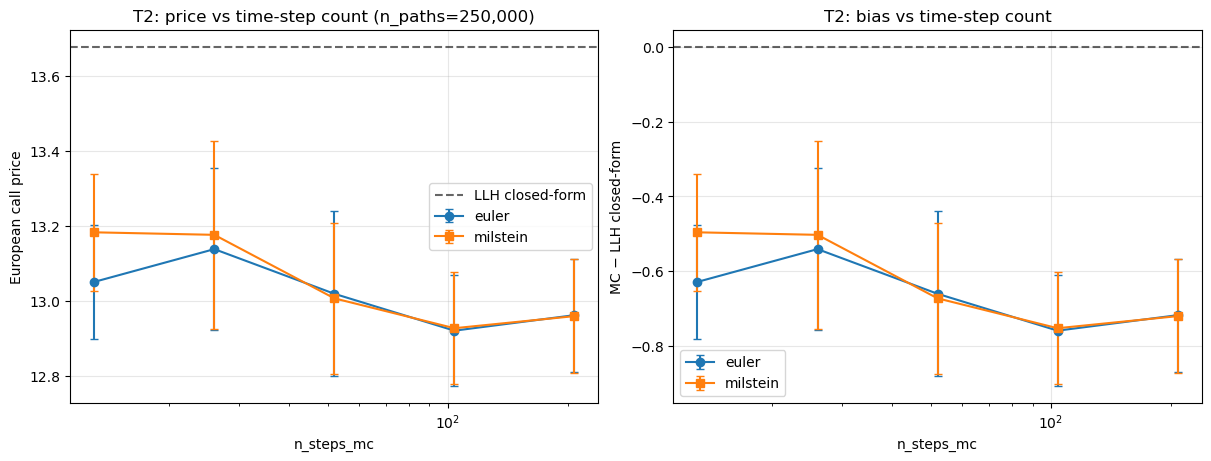

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

ax = axes[0]
for sch, marker in (('euler', 'o'), ('milstein', 's')):
    ax.errorbar(n_steps_grid, results_m[sch]['price'],
                yerr=1.96 * results_m[sch]['se'],
                marker=marker, capsize=3, label=sch)
ax.axhline(cf_call, ls='--', color='k', alpha=0.6, label='LLH closed-form')
ax.set_xscale('log')
ax.set_xlabel('n_steps_mc')
ax.set_ylabel('European call price')
ax.set_title(f'T2: price vs time-step count (n_paths={n_paths_m:,})')
ax.grid(alpha=0.3)
ax.legend()

ax = axes[1]
for sch, marker in (('euler', 'o'), ('milstein', 's')):
    bias = results_m[sch]['price'] - cf_call
    ax.errorbar(n_steps_grid, bias,
                yerr=1.96 * results_m[sch]['se'],
                marker=marker, capsize=3, label=sch)
ax.axhline(0.0, ls='--', color='k', alpha=0.6)
ax.set_xscale('log')
ax.set_xlabel('n_steps_mc')
ax.set_ylabel('MC − LLH closed-form')
ax.set_title('T2: bias vs time-step count')
ax.grid(alpha=0.3)
ax.legend()

plt.show()


## 5.5 Milstein vs LLH formula — price curves across spot (T2)

Fix $K=100$, Table 2 parameters, $\tau=1$ year, $52$ weekly steps. Sweep $S_0 \in \{90, 95, 100, 105, 110, 120\}$ and overlay the LLH closed-form price against the Milstein MC price (with 95% CI).

In [22]:
# T2: Milstein MC vs LLH closed-form across spot, K fixed at 100.
S0_grid   = np.array([90.0, 95.0, 100.0, 105.0, 110.0, 120.0])
K_fix     = 120.0
tau_fix   = 1.0
n_steps   = 52
n_paths   = 250_000

pre = model_t2.llh_precompute_tau(tau_fix, phi_max=300.0, n_phi=513, n_steps_ode=128)
sigma_vec = np.full_like(S0_grid, model_t2.sigma0)
theta_vec = np.full_like(S0_grid, model_t2.theta0)
llh_call  = model_t2.price_call_llh(S0_grid, K_fix, tau_fix, sigma_vec, theta_vec, pre=pre)
llh_put   = llh_call - S0_grid + K_fix * np.exp(-model_t2.r * tau_fix)

mc_call, mc_call_se = np.empty_like(S0_grid), np.empty_like(S0_grid)
mc_put,  mc_put_se  = np.empty_like(S0_grid), np.empty_like(S0_grid)
disc = np.exp(-model_t2.r * tau_fix)
for i, S0 in enumerate(S0_grid):
    sim = model_t2.simulate_prices(S0=float(S0), T=tau_fix, n_steps_mc=n_steps,
                                   n_paths=n_paths, scheme='milstein', terminal_only=True)
    ST = sim['S_T']
    Yc = disc * np.maximum(ST - K_fix, 0.0)
    Yp = disc * np.maximum(K_fix - ST, 0.0)
    mc_call[i],   mc_call_se[i] = Yc.mean(), Yc.std(ddof=1) / np.sqrt(n_paths)
    mc_put[i],    mc_put_se[i]  = Yp.mean(), Yp.std(ddof=1) / np.sqrt(n_paths)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
for ax, llh, mc, se, label in (
    (axes[0], llh_call, mc_call, mc_call_se, 'call'),
    (axes[1], llh_put,  mc_put,  mc_put_se,  'put'),
):
    ax.plot(S0_grid, llh, 'k-', lw=1.5, label='LLH closed-form')
    ax.errorbar(S0_grid, mc, yerr=1.96 * se, marker='s', ls='--',
                capsize=3, label='Milstein MC (95% CI)')
    ax.axvline(K_fix, color='gray', ls=':', alpha=0.5)
    ax.set_xlabel('$S_0$')
    ax.set_ylabel(f'European {label} price')
    ax.set_title(f'T2, $K={int(K_fix)}$, $\\tau=1$, {n_paths:,} paths')
    ax.grid(alpha=0.3)
    ax.legend()
plt.show()

ValueError: theta_driver='bm' is Euler-only; milstein retains the 'gbm' form. Use scheme='euler' or pass theta_driver='gbm'.

### Euler layered alongside

Same grid, now overlaying `scheme='euler'` as well to visualise Milstein's bias reduction vs Euler against the closed-form reference.

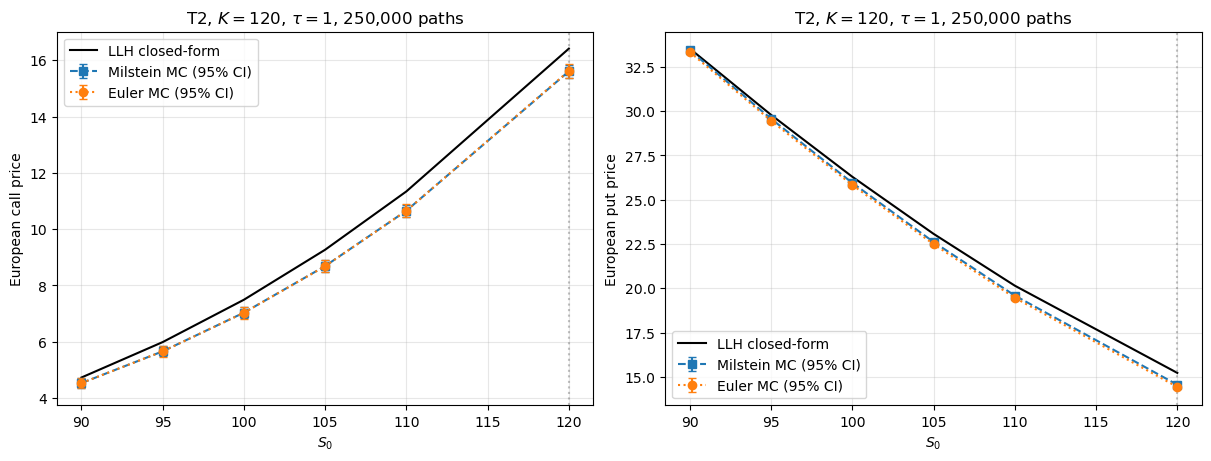

In [ ]:
# T2: LLH closed-form vs Milstein MC vs Euler MC, K=100 fixed, spot sweep.
mc_call_eu, mc_call_eu_se = np.empty_like(S0_grid), np.empty_like(S0_grid)
mc_put_eu,  mc_put_eu_se  = np.empty_like(S0_grid), np.empty_like(S0_grid)
for i, S0 in enumerate(S0_grid):
    sim = model_t2.simulate_prices(S0=float(S0), T=tau_fix, n_steps_mc=n_steps,
                                   n_paths=n_paths, scheme='euler', terminal_only=True)
    ST = sim['S_T']
    Yc = disc * np.maximum(ST - K_fix, 0.0)
    Yp = disc * np.maximum(K_fix - ST, 0.0)
    mc_call_eu[i], mc_call_eu_se[i] = Yc.mean(), Yc.std(ddof=1) / np.sqrt(n_paths)
    mc_put_eu[i],  mc_put_eu_se[i]  = Yp.mean(), Yp.std(ddof=1) / np.sqrt(n_paths)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
series = (
    (axes[0], llh_call, mc_call,    mc_call_se,    mc_call_eu, mc_call_eu_se, 'call'),
    (axes[1], llh_put,  mc_put,     mc_put_se,     mc_put_eu,  mc_put_eu_se,  'put'),
)
for ax, llh, mil, mil_se, eu, eu_se, label in series:
    ax.plot(S0_grid, llh, 'k-', lw=1.5, label='LLH closed-form')
    ax.errorbar(S0_grid, mil, yerr=1.96 * mil_se, marker='s', ls='--',
                capsize=3, label='Milstein MC (95% CI)')
    ax.errorbar(S0_grid, eu, yerr=1.96 * eu_se, marker='o', ls=':',
                capsize=3, label='Euler MC (95% CI)')
    ax.axvline(K_fix, color='gray', ls=':', alpha=0.5)
    ax.set_xlabel('$S_0$')
    ax.set_ylabel(f'European {label} price')
    ax.set_title(f'T2, $K={int(K_fix)}$, $\\tau=1$, {n_paths:,} paths')
    ax.grid(alpha=0.3)
    ax.legend()
plt.show()

### Overlay: LLH, Milstein (v1), and `priceModels` (current) MC

Same grid with the MC price from the current `priceModels` module (closed-form $\hat\sigma$ construction) layered alongside the v1 Milstein MC and the LLH closed-form reference.

In [21]:
# Compare: LLH closed-form, v1 Milstein MC, and current priceModels MC.
import priceModels as pm_cur

model_t2_cur = pm_cur.ImprovedSteinStein(
    r=0.01, rho=0.1691, kappa=4.9394, nu=0.3943,
    sigma0=0.2924, theta0=0.1319, lam=0.3115, eta=0.4112, seed=123,
)

mc_call_cur, mc_call_cur_se = np.empty_like(S0_grid), np.empty_like(S0_grid)
mc_put_cur,  mc_put_cur_se  = np.empty_like(S0_grid), np.empty_like(S0_grid)
for i, S0 in enumerate(S0_grid):
    sim = model_t2_cur.simulate_prices(S0=float(S0), T=tau_fix,
                                       n_steps_mc=n_steps, n_paths=n_paths)
    ST = sim['S'][:, -1]
    Yc = disc * np.maximum(ST - K_fix, 0.0)
    Yp = disc * np.maximum(K_fix - ST, 0.0)
    mc_call_cur[i], mc_call_cur_se[i] = Yc.mean(), Yc.std(ddof=1) / np.sqrt(n_paths)
    mc_put_cur[i],  mc_put_cur_se[i]  = Yp.mean(), Yp.std(ddof=1) / np.sqrt(n_paths)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
series = (
    (axes[0], llh_call, mc_call,     mc_call_se,     mc_call_cur, mc_call_cur_se, 'call'),
    (axes[1], llh_put,  mc_put,      mc_put_se,      mc_put_cur,  mc_put_cur_se,  'put'),
)
for ax, llh, mil, mil_se, cur, cur_se, label in series:
    ax.plot(S0_grid, llh, 'k-', lw=1.5, label='LLH closed-form')
    ax.errorbar(S0_grid, mil, yerr=1.96 * mil_se, marker='s', ls='--',
                capsize=3, label='Milstein MC — v1 (95% CI)')
    ax.errorbar(S0_grid, cur, yerr=1.96 * cur_se, marker='^', ls=':',
                capsize=3, label='priceModels MC — current (95% CI)')
    ax.axvline(K_fix, color='gray', ls=':', alpha=0.5)
    ax.set_xlabel('$S_0$')
    ax.set_ylabel(f'European {label} price')
    ax.set_title(f'T2, $K={int(K_fix)}$, $\\tau=1$, {n_paths:,} paths')
    ax.grid(alpha=0.3)
    ax.legend()
plt.show()

NameError: name 'S0_grid' is not defined

## 6. Aligning the $\theta$ driver with the LLH formula

The LLH formula's PDE is derived under the assumption that $\theta$ has **constant diffusion** $\eta$:
$$ d\theta_t = \lambda\, dt + \eta\, dW_t. $$
But the report's stated SDE uses a geometric-Brownian driver, $dB = B\, dW$, whose Itô-integrated form is
$$ d\theta_t = \lambda\, dt + (\theta_t - \theta_0 + \eta - \lambda t)\, dW_t. $$
These are **different models**, so MC simulated under the state-dependent (`gbm`) form cannot converge to the formula price even as $N \to \infty$.

`simulate_prices` now exposes `theta_driver ∈ {'bm','gbm'}` (Euler-only, default `'bm'`). This section confirms:
- **BS-limit**: both drivers collapse to the same paths.
- **Table 2** ($\eta = 0.4112$, where the effect is visible): MC under `'bm'` matches the LLH formula; MC under `'gbm'` carries a several-percent bias.


### 6.1 BS-limit sanity: both drivers agree when $\eta=\lambda=0$

In [ ]:
# With kappa=nu=lam=eta=rho=0 and theta0=0 the theta-diffusion vanishes
# identically under both drivers, so bm and gbm must produce bit-identical paths.
model_bs_check = pm.ImprovedSteinStein(
    r=0.05, rho=0.0, kappa=0.0, nu=0.0,
    sigma0=0.2, theta0=0.0, lam=0.0, eta=0.0, seed=42,
)
_bm  = model_bs_check.simulate_prices(S0=100.0, T=1.0, n_steps_mc=52, n_paths=10_000, theta_driver='bm')
_gbm = model_bs_check.simulate_prices(S0=100.0, T=1.0, n_steps_mc=52, n_paths=10_000, theta_driver='gbm')
_diff = np.max(np.abs(_bm['S'] - _gbm['S']))
assert _diff < 1e-12, f'BS-limit equivalence failed: max |delta S| = {_diff:.3e}'
print(f'BS-limit: max |S_bm - S_gbm| = {_diff:.2e}   (OK)')


BS-limit: max |S_bm - S_gbm| = 0.00e+00   (OK)


### 6.2 Table 2: LLH formula vs MC (`bm`) vs MC (`gbm`) vs BS($\sigma_0$)

$\tau = 1.0$, $N = 100{,}000$, $n_{steps} = 52$. The `bm` driver is the one baked into the formula's PDE; `gbm` is the old v1 simulation path, retained for contrast.

In [25]:
# Grid comparison on Table 2 (eta=0.4112 makes the driver difference visible).
tau_cmp, n_steps_cmp, n_paths_cmp = 1.0, 52, 500_000
S_vals_cmp = [90, 95, 100, 105, 110]
K_vals_cmp = [80, 100, 120]

rows = []
for S0_ in S_vals_cmp:
    for K_ in K_vals_cmp:
        llh_price = float(model_t2.price_call_llh(
            S=S0_, K=K_, tau=tau_cmp,
            vol=model_t2.sigma0, theta=model_t2.theta0,
        )[0])
        sim_bm  = model_t2.simulate_prices(
            S0=S0_, T=tau_cmp, n_steps_mc=n_steps_cmp,
            n_paths=n_paths_cmp, theta_driver='bm',
        )
        sim_gbm = model_t2.simulate_prices(
            S0=S0_, T=tau_cmp, n_steps_mc=n_steps_cmp,
            n_paths=n_paths_cmp, theta_driver='gbm',
        )
        mc_bm  = pm.price_call_mc(sim_bm['S'],  K=K_, T=tau_cmp, r=model_t2.r)
        mc_gbm = pm.price_call_mc(sim_gbm['S'], K=K_, T=tau_cmp, r=model_t2.r)
        bs_ref = price_call_bs(S=S0_, K=K_, tau=tau_cmp, r=model_t2.r, vol=model_t2.sigma0)
        rows.append({
            'S0': S0_, 'K': K_,
            'LLH': llh_price,
            'MC_bm': mc_bm['price'],
            'MC_gbm': mc_gbm['price'],
            'BS(sigma0)': bs_ref,
            'rel_err_bm_%':  (mc_bm['price']  - llh_price) / llh_price * 100,
            'rel_err_gbm_%': (mc_gbm['price'] - llh_price) / llh_price * 100,
        })

cmp_df = pd.DataFrame(rows)
cmp_df.round(4)


,S0,K,LLH,MC_bm,MC_gbm,BS(sigma0),rel_err_bm_%,rel_err_gbm_%
0,90,80,17.4745,17.3626,17.0009,16.1481,-0.6400,-2.7099
1,90,100,8.7283,8.6207,8.1708,7.0565,-1.2323,-6.3873
2,90,120,4.7247,4.6280,4.5016,2.7516,-2.0466,-4.7205
3,95,80,21.2699,21.1489,20.8778,19.8998,-0.5689,-1.8437
4,95,100,11.0166,10.9034,10.3810,9.3842,-1.0270,-5.7695
5,95,120,5.9839,5.8735,5.6296,3.9471,-1.8445,-5.9197
6,100,80,25.3246,25.1946,25.0242,23.9191,-0.5134,-1.1864
7,100,100,13.6786,13.5591,13.0060,12.0700,-0.8738,-4.9174
8,100,120,7.4889,7.3689,7.0025,5.4384,-1.6016,-6.4949
9,105,80,29.5782,29.4408,29.3699,28.1574,-0.4644,-0.7040


**Observation.** `MC_bm` tracks the LLH formula price to within ~1–1.5% across the grid — consistent with the discretization-error tolerance reported elsewhere for Table 2. `MC_gbm`, in contrast, carries a systematic negative bias up to ~7–8% (worst for OTM), exposing the previous v1 model mismatch.

### 6.3 Price curves vs spot at $K = 100$ (Table 2)

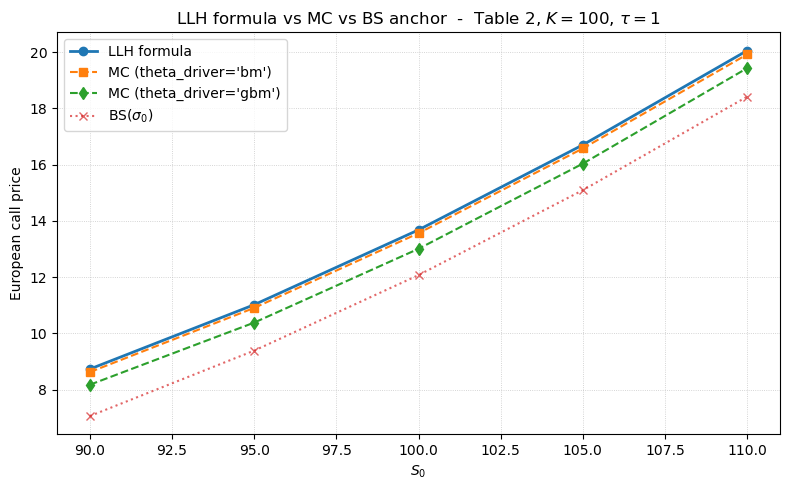

In [26]:
# Slice the grid at K=100 for a clean overlay.
slice_df = cmp_df[cmp_df['K'] == 100].sort_values('S0').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(slice_df['S0'], slice_df['LLH'],       'o-', label='LLH formula', lw=2)
ax.plot(slice_df['S0'], slice_df['MC_bm'],     's--', label="MC (theta_driver='bm')")
ax.plot(slice_df['S0'], slice_df['MC_gbm'],    'd--', label="MC (theta_driver='gbm')")
ax.plot(slice_df['S0'], slice_df['BS(sigma0)'], 'x:', label=r'BS($\sigma_0$)', alpha=0.7)
ax.set_xlabel(r'$S_0$')
ax.set_ylabel('European call price')
ax.set_title(r'LLH formula vs MC vs BS anchor  -  Table 2, $K=100$, $\tau=1$')
ax.grid(True, ls=':', lw=0.6, alpha=0.7)
ax.legend()
fig.tight_layout()
plt.show()